# Generating SQL for Postgres using OpenAI, Qdrant
This notebook runs through the process of using the `vanna` Python package to generate SQL using AI (RAG + LLMs) including connecting to a database and training. If you're not ready to train on your own database, you can still try it using a sample [SQLite database](app.md).

## Setup

In [1]:
%pip install 'vanna[qdrant,openai,postgres]'

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from vanna.openai import OpenAI_Chat
from vanna.qdrant import Qdrant_VectorStore
from qdrant_client import QdrantClient
from openai import OpenAI

In [9]:
# 1. Create your OpenAI client
openai_client = OpenAI(
    api_key="sk-69sdg9WEEGkc-T67WBst0w",
    base_url="http://litellm.default.svc.cluster.local:4000/v1"
)

# 2. Create your Qdrant client
qdrant_client = QdrantClient(
    host="qdrant.default.svc.cluster.local",
    port=6333
)

# 3. Custom hybrid class
class MyVanna(Qdrant_VectorStore, OpenAI_Chat):
    def __init__(self, config=None):
        # Pass the correct client to each superclass
        Qdrant_VectorStore.__init__(self, config={"client": config["qdrant_client"]})
        OpenAI_Chat.__init__(self, client=config["openai_client"], config={"model": config["model"]})

# 4. Instantiate
vn = MyVanna(config={
    "qdrant_client": qdrant_client,
    "openai_client": openai_client,
    "model": "gpt-4o"
})

In [10]:
vn.connect_to_postgres(host='postgresql.default.svc.cluster.local', dbname='postgres', user='postgres', password='FMGp9r8oR2', port='5432')

## Training
You only need to train once. Do not train again unless you want to add more training data.

In [11]:

# The information schema query may need some tweaking depending on your database. This is a good starting point.
df_information_schema = vn.run_sql("SELECT * FROM INFORMATION_SCHEMA.COLUMNS")

# This will break up the information schema into bite-sized chunks that can be referenced by the LLM
plan = vn.get_training_plan_generic(df_information_schema)
plan

# If you like the plan, then uncomment this and run it to train
# vn.train(plan=plan)



Train on Information Schema: postgres.information_schema domain_udt_usage
Train on Information Schema: postgres.information_schema table_privileges
Train on Information Schema: postgres.information_schema parameters
Train on Information Schema: postgres.information_schema routine_privileges
Train on Information Schema: postgres.information_schema collation_character_set_applicability
Train on Information Schema: postgres.information_schema sql_implementation_info
Train on Information Schema: postgres.information_schema schemata
Train on Information Schema: postgres.information_schema role_udt_grants
Train on Information Schema: postgres.information_schema routines
Train on Information Schema: postgres.information_schema element_types
Train on Information Schema: postgres.information_schema sql_features
Train on Information Schema: postgres.information_schema column_domain_usage
Train on Information Schema: postgres.information_schema role_column_grants
Train on Information Schema: post

In [13]:

# The following are methods for adding training data. Make sure you modify the examples to match your database.

# DDL statements are powerful because they specify table names, colume names, types, and potentially relationships
vn.train(ddl="""
    CREATE TABLE customers (
      customer_id SERIAL NOT NULL PRIMARY KEY,
      customer_name VARCHAR(255),
      contact_name VARCHAR(255),
      address VARCHAR(255),
      city VARCHAR(255),
      postal_code VARCHAR(255),
      country VARCHAR(255)
    );
    CREATE TABLE products (
      product_id SERIAL NOT NULL PRIMARY KEY,
      product_name VARCHAR(255),
      category_id INT,
      unit VARCHAR(255),
      price DECIMAL(10, 2)
    );
    CREATE TABLE orders (
      order_id SERIAL NOT NULL PRIMARY KEY,
      customer_id INT,
      order_date DATE
    );
    CREATE TABLE categories (
      category_id SERIAL NOT NULL PRIMARY KEY,
      category_name VARCHAR(255),
      description VARCHAR(255)
    );
    CREATE TABLE order_details (
      order_detail_id SERIAL NOT NULL PRIMARY KEY,
      order_id INT,
      product_id INT,
      quantity INT
    );
    CREATE TABLE testproducts (
      testproduct_id SERIAL NOT NULL PRIMARY KEY,
      product_name VARCHAR(255),
      category_id INT
    );
""")

# Sometimes you may want to add documentation about your business terminology or definitions.
#vn.train(documentation="Our business defines OTIF score as the percentage of orders that are delivered on time and in full")

# You can also add SQL queries to your training data. This is useful if you have some queries already laying around. You can just copy and paste those from your editor to begin generating new SQL.
#vn.train(sql="SELECT * FROM my-table WHERE name = 'John Doe'")


Adding ddl: 
    CREATE TABLE customers (
      customer_id SERIAL NOT NULL PRIMARY KEY,
      customer_name VARCHAR(255),
      contact_name VARCHAR(255),
      address VARCHAR(255),
      city VARCHAR(255),
      postal_code VARCHAR(255),
      country VARCHAR(255)
    );
    CREATE TABLE products (
      product_id SERIAL NOT NULL PRIMARY KEY,
      product_name VARCHAR(255),
      category_id INT,
      unit VARCHAR(255),
      price DECIMAL(10, 2)
    );
    CREATE TABLE orders (
      order_id SERIAL NOT NULL PRIMARY KEY,
      customer_id INT,
      order_date DATE
    );
    CREATE TABLE categories (
      category_id SERIAL NOT NULL PRIMARY KEY,
      category_name VARCHAR(255),
      description VARCHAR(255)
    );
    CREATE TABLE order_details (
      order_detail_id SERIAL NOT NULL PRIMARY KEY,
      order_id INT,
      product_id INT,
      quantity INT
    );
    CREATE TABLE testproducts (
      testproduct_id SERIAL NOT NULL PRIMARY KEY,
      product_name VARCHAR(255)

'1438cace-5b6d-591c-a2ff-3df8892224ea-ddl'

In [14]:
# At any time you can inspect what training data the package is able to reference
training_data = vn.get_training_data()
training_data

,id,question,content,training_data_type
0,fe076f59-162e-58cc-ab0a-f0a716179882-sql,who are top 3 customer,"SELECT c.customer_id, c.customer_name, SUM(od....",sql
0,1438cace-5b6d-591c-a2ff-3df8892224ea-ddl,None,\n CREATE TABLE customers (\n customer...,ddl


In [ ]:
# You can remove training data if there's obsolete/incorrect information. 
# vn.remove_training_data(id='1-ddl')


## Asking the AI
Whenever you ask a new question, it will find the 10 most relevant pieces of training data and use it as part of the LLM prompt to generate the SQL.

SQL Prompt: [{'role': 'system', 'content': "You are a PostgreSQL expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \n\n    CREATE TABLE customers (\n      customer_id SERIAL NOT NULL PRIMARY KEY,\n      customer_name VARCHAR(255),\n      contact_name VARCHAR(255),\n      address VARCHAR(255),\n      city VARCHAR(255),\n      postal_code VARCHAR(255),\n      country VARCHAR(255)\n    );\n    CREATE TABLE products (\n      product_id SERIAL NOT NULL PRIMARY KEY,\n      product_name VARCHAR(255),\n      category_id INT,\n      unit VARCHAR(255),\n      price DECIMAL(10, 2)\n    );\n    CREATE TABLE orders (\n      order_id SERIAL NOT NULL PRIMARY KEY,\n      customer_id INT,\n      order_date DATE\n    );\n    CREATE TABLE categories (\n      category_id SERIAL NOT NULL PRIMARY KEY,\n      category_name VARCHAR(255),\n      description VARCHAR(2

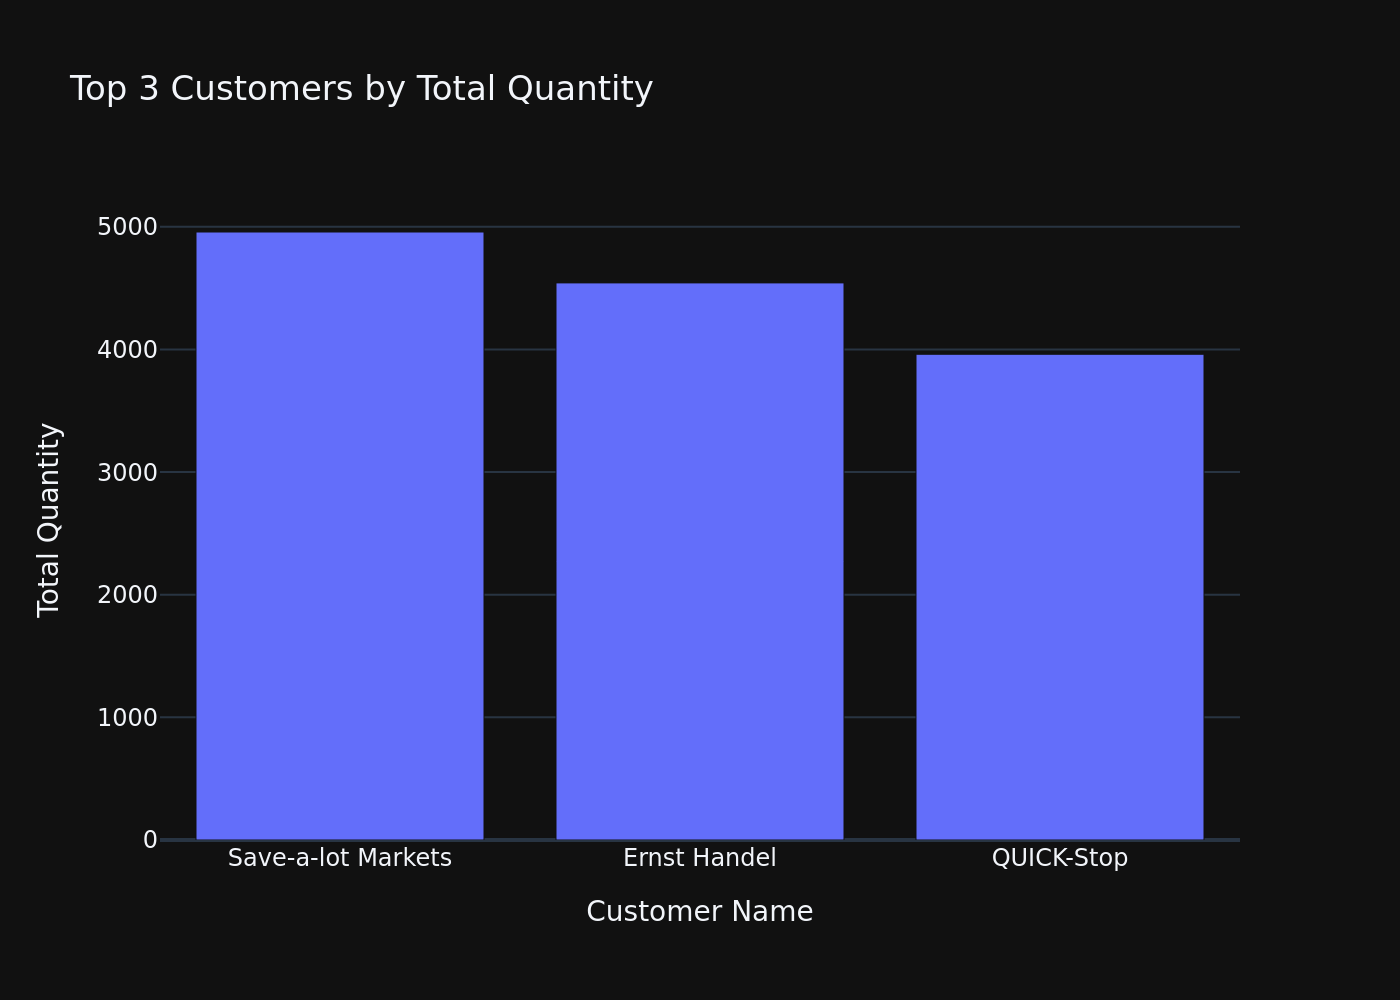

('SELECT c.customer_id, c.customer_name, SUM(od.quantity) AS total_quantity\nFROM customers c\nJOIN orders o ON c.customer_id = o.customer_id\nJOIN order_details od ON o.order_id = od.order_id\nGROUP BY c.customer_id, c.customer_name\nORDER BY total_quantity DESC\nLIMIT 3;',
    customer_id       customer_name  total_quantity
 0           71  Save-a-lot Markets            4958
 1           20        Ernst Handel            4543
 2           63          QUICK-Stop            3961,
 Figure({
     'data': [{'hovertemplate': 'customer_name=%{x}<br>total_quantity=%{y}<extra></extra>',
               'legendgroup': '',
               'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
               'name': '',
               'orientation': 'v',
               'showlegend': False,
               'textposition': 'auto',
               'type': 'bar',
               'x': array(['Save-a-lot Markets', 'Ernst Handel', 'QUICK-Stop'], dtype=object),
               'xaxis': 'x',
               

In [15]:
vn.ask(question='who are top 3 customer')

## Launch the User Interface
![vanna-flask](https://vanna.ai/blog/img/vanna-flask.gif)

In [ ]:
from vanna.flask import VannaFlaskApp
app = VannaFlaskApp(vn)
app.run()

Your app is running at:
http://localhost:8084
 * Serving Flask app 'vanna.flask'
 * Debug mode: on


## Next Steps
Using Vanna via Jupyter notebooks is great for getting started but check out additional customizable interfaces like the 
- [Streamlit app](https://github.com/vanna-ai/vanna-streamlit)
- [Flask app](https://github.com/vanna-ai/vanna-flask)
- [Slackbot](https://github.com/vanna-ai/vanna-slack)
